In [1]:
import IPython
import torch
import matplotlib.pyplot as plt


from configs import Configs as cfg
from simple_tts import SimpleTTS
from utils.write_mp3 import write_mp3
from utils.text_to_seq import text_to_seq
from utils.melspecs import inverse_mel_spec_to_wav

100%|██████████| 100/100 [00:02<00:00, 46.78it/s]


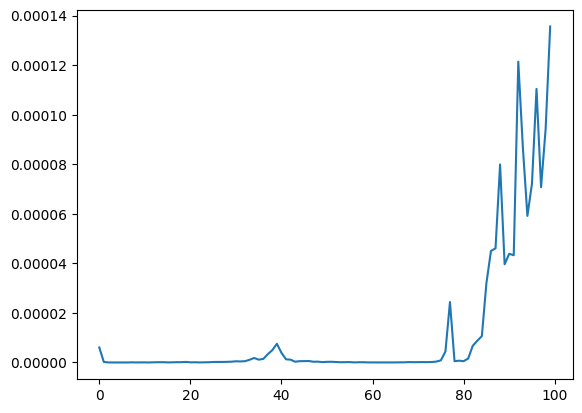

In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
train_saved_path = "/app/Simple-TTS/_saved_dir/params/test_SimpleTTS.pt"
state = torch.load(train_saved_path)
model = SimpleTTS(
            text_num_embeddings=cfg.text_num_embeddings,
            embedding_size=cfg.embedding_size,
            encoder_embedding_size=cfg.encoder_embedding_size,
            mel_freq=cfg.mel_freq,
            max_mel_time=cfg.max_mel_time,
            dim_feedforward=cfg.dim_feedforward,
            postnet_embedding_size=cfg.postnet_embedding_size,
            encoder_kernel_size=cfg.encoder_kernel_size,
            postnet_kernel_size=cfg.postnet_kernel_size
        ).to(device)
model.load_state_dict(state["model"])

text = "Hello, World!"
name_file = "/app/Simple-TTS/_saved_dir/samples/hello_world.mp3"


postnet_mel, gate = model.inference(
  text_to_seq(text).unsqueeze(0).to(device),
  max_length=100,
  stop_token_threshold=0.7,
  with_tqdm = True
)

audio = inverse_mel_spec_to_wav(postnet_mel.detach()[0].T, device)

plt.plot(
    torch.sigmoid(gate[0, :]).detach().cpu().numpy()
)

write_mp3(
    audio.detach().cpu().numpy(),
    name_file
)

IPython.display.Audio(
    audio.detach().cpu().numpy(),
    rate=cfg.sr
)

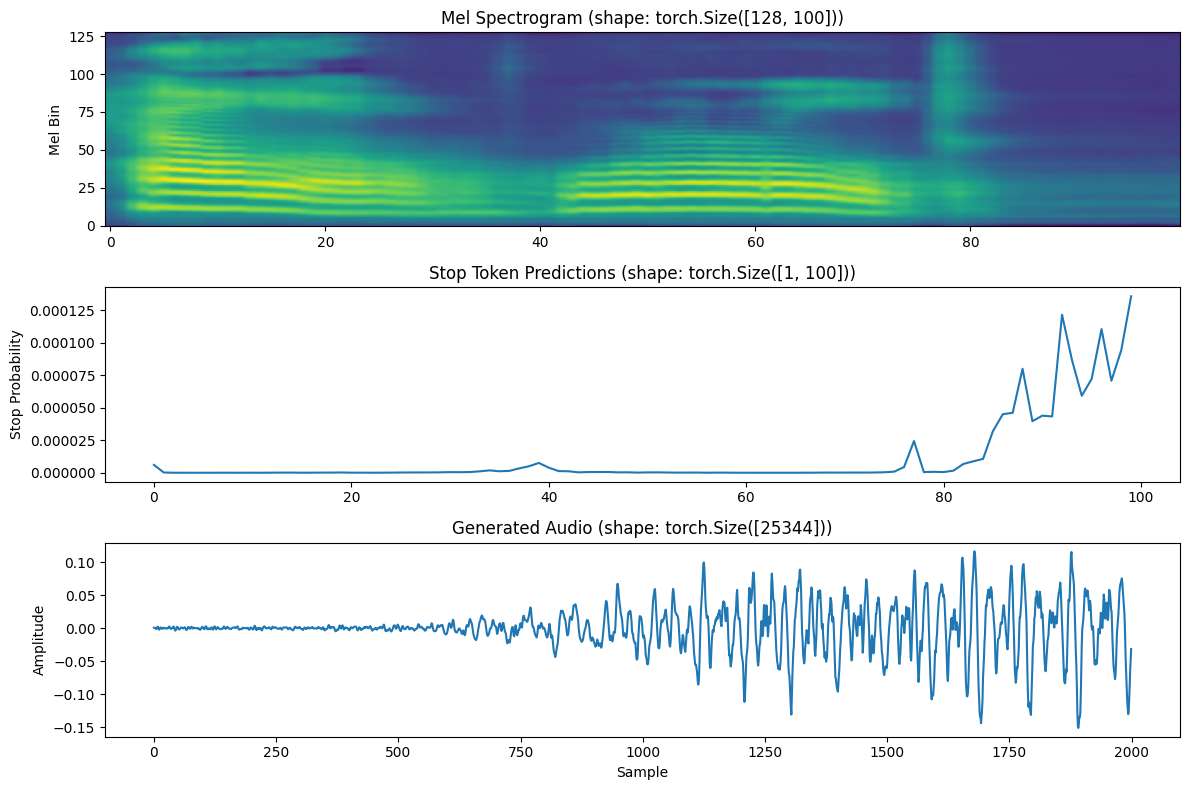

In [3]:

mel_transposed = postnet_mel.detach()[0].T
audio = inverse_mel_spec_to_wav(mel_transposed, device)
gate_probs = torch.sigmoid(gate[0, :]).detach().cpu().numpy()
audio_cpu = audio.detach().cpu().numpy()

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.imshow(mel_transposed.detach().cpu().numpy(), aspect='auto', origin='lower')
plt.title(f"Mel Spectrogram (shape: {mel_transposed.shape})")
plt.ylabel("Mel Bin")

plt.subplot(3, 1, 2)
plt.plot(gate_probs)
plt.title(f"Stop Token Predictions (shape: {gate.shape})")
plt.ylabel("Stop Probability")

plt.subplot(3, 1, 3)
plt.plot(audio_cpu[:min(2000, len(audio_cpu))])
plt.title(f"Generated Audio (shape: {audio.shape})")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()